<a href="https://colab.research.google.com/github/SpiderFang/MolecularDescriptors-rdkit/blob/main/molecular_descritors_rdkit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating Molecular Descriptors Using RDKit


In [ ]:
# Install RDKit
!pip install rdkit

In [ ]:
# Importing Libraries
import pandas as pd
import warnings

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem, PandasTools
from rdkit.ML.Descriptors import MoleculeDescriptors

warnings.filterwarnings("ignore")

In [ ]:
import os
import pandas as pd # Ensure pandas is imported here if not globally

# Install openpyxl if not already installed
# openpyxl is needed to read .xlsx files
!pip install openpyxl

# Check if the file exists before attempting to read it.
# If you haven't uploaded 'Heteroaromatics.xlsx' yet, please do so.
# You can upload it by clicking the folder icon on the left sidebar,
# then selecting the 'Upload' icon and choosing your file.

file_path = '/content/Heteroaromatics.xlsx'

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found. Please upload it to Colab.")
    # If you uploaded the file to a different path, update 'file_path' accordingly.
    raise FileNotFoundError(f"File not found: {file_path}. Please upload the file 'Heteroaromatics.xlsx'.")
else:
    # Specify the engine as 'openpyxl' for .xlsx files
    df = pd.read_excel(file_path, engine='openpyxl')
    print(f"Successfully loaded '{file_path}'.")

Successfully loaded '/content/Heteroaromatics.xlsx'.


In [ ]:
df.head()

,Smiles
0,CN1C=CC=C1
1,C1=CC=CN1
2,C1=CN=CC=C1
3,CC1=NC=CC=C1
4,CC1=CC=NC=C1


In [ ]:
# Creating molecular object from Smiles

# PandasTools.AddMoleculeColumnToFrame(df,'Smiles','mol')

In [ ]:
df

,Smiles
0,CN1C=CC=C1
1,C1=CC=CN1
2,C1=CN=CC=C1
3,CC1=NC=CC=C1
4,CC1=CC=NC=C1
5,CC1=C(C)C=NC=C1
6,CC1=NC(C)=CC=C1
7,CC(C)(C)C1=NC(C(C)(C)C)=CC=C1
8,CC1=NC(C)=CC(C)=C1
9,FC1=NC=CC=C1


Create an object of the molecule descriptor class

In [ ]:
mol_list = []

for smile in df['Smiles']:
  mol = Chem.MolFromSmiles(smile)
  mol = Chem.AddHs(mol)
  mol_list.append(mol)

df = pd.concat([df, pd.DataFrame(mol_list, columns = (['mol']))], axis=1)

In [ ]:
df.head()

,Smiles,mol
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5ac70>
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x789e47e59a80>
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5aab0>
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5b300>
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5a810>


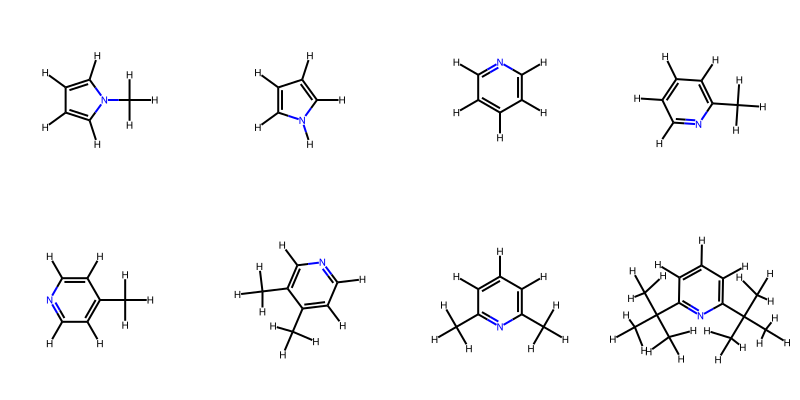

In [ ]:
Draw.MolsToGridImage(df['mol'][:8],molsPerRow=4,subImgSize=(200,200))

Create an instance of the class to print names and number of descriptors

In [ ]:
Desc_list_func = MoleculeDescriptors.MolecularDescriptorCalculator(x[0] for x in Descriptors._descList)

In [ ]:
Desc_list_func

Call the instance to get names

In [ ]:
names = Desc_list_func.GetDescriptorNames()

Print the names of descriptors

In [ ]:
names

('MaxAbsEStateIndex',
 'MaxEStateIndex',
 'MinAbsEStateIndex',
 'MinEStateIndex',
 'qed',
 'SPS',
 'MolWt',
 'HeavyAtomMolWt',
 'ExactMolWt',
 'NumValenceElectrons',
 'NumRadicalElectrons',
 'MaxPartialCharge',
 'MinPartialCharge',
 'MaxAbsPartialCharge',
 'MinAbsPartialCharge',
 'FpDensityMorgan1',
 'FpDensityMorgan2',
 'FpDensityMorgan3',
 'BCUT2D_MWHI',
 'BCUT2D_MWLOW',
 'BCUT2D_CHGHI',
 'BCUT2D_CHGLO',
 'BCUT2D_LOGPHI',
 'BCUT2D_LOGPLOW',
 'BCUT2D_MRHI',
 'BCUT2D_MRLOW',
 'AvgIpc',
 'BalabanJ',
 'BertzCT',
 'Chi0',
 'Chi0n',
 'Chi0v',
 'Chi1',
 'Chi1n',
 'Chi1v',
 'Chi2n',
 'Chi2v',
 'Chi3n',
 'Chi3v',
 'Chi4n',
 'Chi4v',
 'HallKierAlpha',
 'Ipc',
 'Kappa1',
 'Kappa2',
 'Kappa3',
 'LabuteASA',
 'PEOE_VSA1',
 'PEOE_VSA10',
 'PEOE_VSA11',
 'PEOE_VSA12',
 'PEOE_VSA13',
 'PEOE_VSA14',
 'PEOE_VSA2',
 'PEOE_VSA3',
 'PEOE_VSA4',
 'PEOE_VSA5',
 'PEOE_VSA6',
 'PEOE_VSA7',
 'PEOE_VSA8',
 'PEOE_VSA9',
 'SMR_VSA1',
 'SMR_VSA10',
 'SMR_VSA2',
 'SMR_VSA3',
 'SMR_VSA4',
 'SMR_VSA5',
 'SMR_VSA6',


In [ ]:
len(names)

217

Again create an object of the molecule descriptor class

1. Get Summary of the descriptors
2. Generate molecular descriptors

In [ ]:
MoleculeDescriptors.MolecularDescriptorCalculator(['MolLogP']).GetDescriptorSummaries()

['Wildman-Crippen LogP value']

In [ ]:
# create another instance for calculating molecular descriptors

Des_func = MoleculeDescriptors.MolecularDescriptorCalculator(['NumHeteroatoms', 'NumHDonors'])

In [ ]:
Des_func

Calculate one descriptor for a sinlge molecule

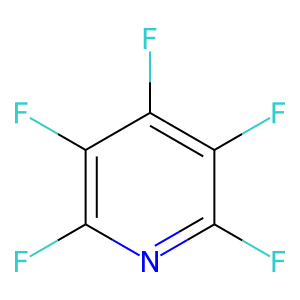

(6, 0)

In [ ]:
display(Draw.MolToImage(df['mol'][12]))
Des_func.CalcDescriptors(df['mol'][12])

Calculate one or more descriptor for the whole dataset

In [ ]:
des = []

for mol in df['mol']:
  des.append(Des_func.CalcDescriptors(mol))

In [ ]:
Final_df = pd.concat([df, pd.DataFrame(des, columns=(['NumHeteroatoms', 'NumHDonors']))], axis=1)

In [ ]:
Final_df.head()

,Smiles,mol,NumHeteroatoms,NumHDonors
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5ac70>,1,0
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x789e47e59a80>,1,1
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5aab0>,1,0
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5b300>,1,0
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5a810>,1,0


Calculate all the descriptor for the whole dataset

In [ ]:
# create another instance for calculating molecular descriptors

Des_func = MoleculeDescriptors.MolecularDescriptorCalculator(x[0] for x in Descriptors._descList)

In [ ]:
des = []

for mol in df['mol']:
  des.append(Des_func.CalcDescriptors(mol))

In [ ]:
Final_df = pd.concat([df, pd.DataFrame(des, columns=(x[0] for x in Descriptors._descList))], axis=1)

In [ ]:
Final_df.head()

,Smiles,mol,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,CN1C=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5ac70>,7.188079,7.188079,0.386574,-2.663426,0.439206,27.666667,81.118,74.062,...,0,0,0,0,0,0,0,0,0,0
1,C1=CC=CN1,<rdkit.Chem.rdchem.Mol object at 0x789e47e59a80>,6.969907,6.969907,0.361111,-0.407407,0.465869,22.000000,67.091,62.051,...,0,0,0,0,0,0,0,0,0,0
2,C1=CN=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5aab0>,7.070741,7.070741,0.397222,-0.420370,0.453148,19.666667,79.102,74.062,...,0,0,0,0,0,0,0,0,0,0
3,CC1=NC=CC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5b300>,7.275116,7.275116,0.525000,-2.614699,0.471998,24.857143,93.129,86.073,...,0,0,0,0,0,0,0,0,0,0
4,CC1=CC=NC=C1,<rdkit.Chem.rdchem.Mol object at 0x789e47e5a810>,7.275116,7.275116,0.581019,-2.650093,0.471998,24.857143,93.129,86.073,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
Final_df.drop('mol', axis=1).to_excel('final.xlsx', index=None)

讀取 final Excel 檔, 使用 PCA (主成分分析) 並畫出分子的 PCA 分佈圖

Successfully loaded 'final.xlsx'.


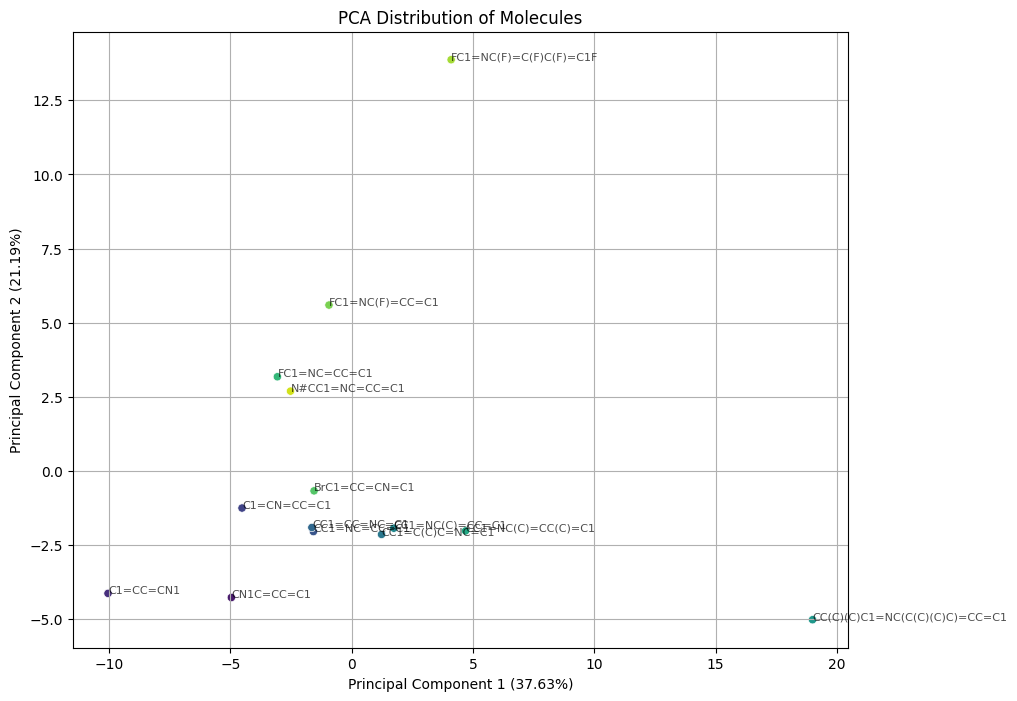

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load the final.xlsx file
try:
    df_final = pd.read_excel('/content/final.xlsx')
    print("Successfully loaded 'final.xlsx'.")
except FileNotFoundError:
    print("Error: 'final.xlsx' not found. Please ensure the file exists in the current directory.")
    raise

# Drop non-descriptor columns (like 'Smiles' and 'mol' if it was kept in excel)
# Assuming 'mol' column was dropped before saving to excel, but checking just in case
if 'Smiles' in df_final.columns:
    df_descriptors = df_final.drop(columns=['Smiles'])
else:
    df_descriptors = df_final.copy()

# If 'mol' column is still present (unlikely if saved to excel, but for robustness)
if 'mol' in df_descriptors.columns:
    df_descriptors = df_descriptors.drop(columns=['mol'])

# Check if there are any descriptors to process
if df_descriptors.empty:
    raise ValueError("No molecular descriptor columns found after dropping 'Smiles' and 'mol'.")

# Standardize the descriptor data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_descriptors)

# Apply PCA
# 初始化 PCA 物件，並設定 n_components=2，表示將資料降維到兩個主成分。這兩個主成分將用於二維圖的繪製。
pca = PCA(n_components=2) # Get top 2 principal components for 2D plotting
# 將標準化後的資料 (X_scaled) 應用到 PCA 模型中，得到降維後的資料 X_pca。
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])

# Add the original smiles for labeling if available
if 'Smiles' in df_final.columns:
    df_pca['Smiles'] = df_final['Smiles']

# Plot the PCA distribution
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', data=df_pca, hue='Smiles' if 'Smiles' in df_pca.columns else None, palette='viridis', legend=None)

# Annotate points with Smiles if there are not too many molecules
if 'Smiles' in df_pca.columns and len(df_pca) < 50:
    for i, row in df_pca.iterrows():
        plt.text(row['Principal Component 1'], row['Principal Component 2'], row['Smiles'], fontsize=8, alpha=0.7)

plt.title('PCA Distribution of Molecules')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True)
plt.show()

查看 `pca.explained_variance_ratio_` 以了解兩個主成分解釋了多少變異量

這段程式碼將會顯示每個主成分解釋的變異量比例，以及這兩個主成分總共解釋了多少變異量。

PCA 結果顯示，第一個主成分解釋了約 37.63% 的變異量，而第二個主成分解釋了約 21.19% 的變異量。這兩個主成分加起來總共解釋了原始數據中約 58.82% 的變異量。這表示這兩個主成分在一定程度上能代表原始數據中的主要信息，但也說明還有其他主成分能夠解釋剩餘的變異。


In [5]:
print(f"Explained variance ratio per principal component: {pca.explained_variance_ratio_}")
print(f"Total explained variance by the first two principal components: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

Explained variance ratio per principal component: [0.37626295 0.21193084]
Total explained variance by the first two principal components: 58.82%


### 增加主成分數量以解釋更多變異量

重新執行 PCA，這次會增加主成分的數量，並顯示每個主成分解釋的變異量比例，以及總共解釋的變異量。

當主成分數量增加到 5 個時，它們總共解釋了原始數據中 88.48% 的變異量。這顯著高於只使用兩個主成分時的 58.82%，表示使用 5 個主成分可以更好地捕捉原始數據中的信息。

詳細的變異量解釋如下：

第一個主成分：37.63%
第二個主成分：21.19%
第三個主成分：12.94%
第四個主成分：9.34%
第五個主成分：7.37%
這些結果表明，前幾個主成分確實包含了數據中的主要信息，並且隨著主成分數量的增加，模型對數據變異的解釋能力也隨之提高。

In [6]:
# 嘗試增加主成分數量，例如設定為 5
pca_expanded = PCA(n_components=5)
X_pca_expanded = pca_expanded.fit_transform(X_scaled)

print(f"Explained variance ratio per principal component (5 components): {pca_expanded.explained_variance_ratio_}")
print(f"Total explained variance by the first five principal components: {pca_expanded.explained_variance_ratio_.sum() * 100:.2f}%")

Explained variance ratio per principal component (5 components): [0.37626295 0.21193084 0.12942006 0.09343697 0.07372401]
Total explained variance by the first five principal components: 88.48%


### 檢查描述符中的缺失值

In [ ]:
print('Checking for missing values in descriptor data:')
missing_values = df_descriptors.isnull().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print('No missing values found in the descriptor data.')
else:
    display(missing_values.sort_values(ascending=False))


Checking for missing values in descriptor data:
No missing values found in the descriptor data.


### 檢查異常值 (通過描述性統計)

In [ ]:
print('Descriptive statistics of the descriptor data:')
display(df_descriptors.describe())


Descriptive statistics of the descriptor data:


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,14.0,14.0,14.0,14.0,14.0,14.0,14.0,14.0,14.0,14.0
mean,8.466023,8.466023,0.703444,-1.925723,0.485114,22.987876,113.122714,106.210714,112.978777,41.571429,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,2.070927,2.070927,0.499582,1.216581,0.049217,8.166459,35.985780,34.572037,35.877369,13.340017,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,6.969907,6.969907,0.157407,-4.090975,0.425695,10.272727,67.091000,62.051000,67.042199,26.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,7.227303,7.227303,0.389236,-2.748756,0.456111,16.714286,93.129000,86.073000,93.057849,36.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,7.402199,7.402199,0.553009,-2.406887,0.471998,23.428571,105.634000,98.084000,105.555474,37.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,8.313080,8.313080,0.770139,-0.620683,0.491388,28.479167,119.657750,111.567250,119.572701,42.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,12.398426,12.398426,1.998704,-0.330370,0.609355,40.428571,191.318000,170.150000,191.167400,78.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


描述性統計數據 (如最小值、最大值、標準差和四分位數) 可以幫助我們初步識別潛在的異常值。對於更詳細的異常值分析，您可能需要對特定描述符繪製箱形圖或使用更進階的異常值檢測方法。